In [1]:
import pandas as pd, numpy as np
from sqlalchemy import create_engine
engine = create_engine("postgresql+psycopg2://postgres@127.0.0.1:5432/trading")

px = pd.read_sql("SELECT date, adj_close FROM prices WHERE ticker='SPY' ORDER BY date",
                 engine, parse_dates=["date"], index_col="date")["adj_close"].astype(float)

In [2]:
ema50  = px.ewm(span=50,  adjust=False).mean()
ema200 = px.ewm(span=200, adjust=False).mean()

signal = (ema50 > ema200).astype(int)   # 1 = long, 0 = flat, decided at today's close
signal.iloc[:200] = 0                   # warm-up: no trades in the first 200 days
position = signal.shift(1).fillna(0)    # the position you actually hold tomorrow

In [3]:
ret = px.pct_change().fillna(0)
cost_rate = 0.0005                      # 0.05% per position change
trades = position.diff().abs().fillna(0)

strat_ret = position * ret - trades * cost_rate
bh_ret = ret                            # buy-and-hold for comparison

strategy    4.603901
buy_hold    8.356251
Name: 2025-12-31 00:00:00, dtype: float64
trades: 21 | time in market: 79.3 %


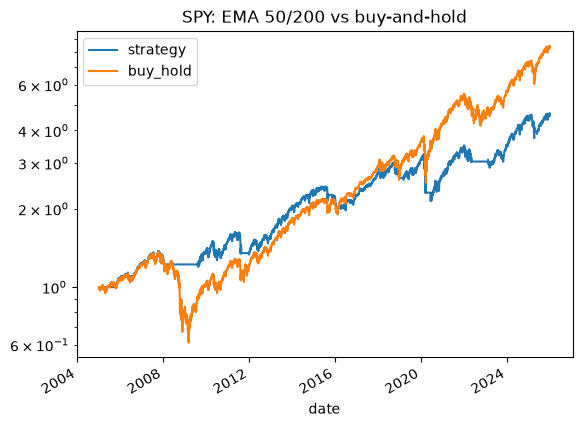

In [4]:
eq = pd.DataFrame({"strategy": (1 + strat_ret).cumprod(),
                   "buy_hold": (1 + bh_ret).cumprod()})
print(eq.iloc[-1])
print("trades:", int(trades.sum()), "| time in market:", round(position.mean() * 100, 1), "%")
eq.plot(logy=True, title="SPY: EMA 50/200 vs buy-and-hold");

In [5]:
def metrics(r, rf=0.0):
    r = r.dropna()
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1 / years) - 1
    sharpe = (r.mean() - rf / 252) / r.std() * np.sqrt(252)
    max_dd = (eq / eq.cummax() - 1).min()
    return pd.Series({"CAGR": cagr, "Sharpe": sharpe, "MaxDD": max_dd, "EndValue": eq.iloc[-1]})

start = px.index[200]
pd.DataFrame({"strategy": metrics(strat_ret[start:]),
              "buy_hold": metrics(bh_ret[start:])}).round(3)

,strategy,buy_hold
CAGR,0.079,0.111
Sharpe,0.611,0.641
MaxDD,-0.339,-0.552
EndValue,4.604,8.337


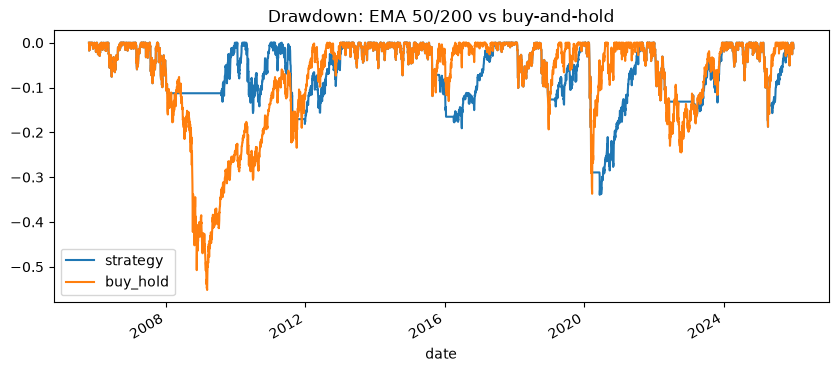

In [6]:
eq2 = pd.DataFrame({"strategy": (1 + strat_ret[start:]).cumprod(),
                    "buy_hold": (1 + bh_ret[start:]).cumprod()})
dd = eq2 / eq2.cummax() - 1
dd.plot(title="Drawdown: EMA 50/200 vs buy-and-hold", figsize=(10, 4));